# Examples for incorporating monai image augmentation suite for training

## Dependencies

In [ ]:
import re
import pathlib
from typing import List

import pandas as pd
from monai.transforms import (
    Compose, 
    EnsureTyped, 
    RandFlipd, 
    RandRotate90d, 
    RandAffined,
    RandGaussianNoised,
    RandGaussianSmoothd,
    RandAdjustContrastd
)

from virtual_stain_flow.datasets.base_dataset import BaseImageDataset
from virtual_stain_flow.datasets.crop_dataset import CropImageDataset
from virtual_stain_flow.datasets.monai_aug_adapter_dataset import MonaiAdapter
from virtual_stain_flow.transforms.normalizations import MaxScaleNormalize
from virtual_stain_flow.evaluation.visualization import plot_dataset_grid


## Pathing and Additional utils

In [ ]:
DATA_PATH = pathlib.Path("/YOUR/DATA/PATH/")  # Change to where the download_data script outputs data

# Sanity check for data existence
if not DATA_PATH.exists() or not DATA_PATH.is_dir():
    raise FileNotFoundError(f"Data path {DATA_PATH} does not exist or is not a directory.")

# Matches filenames like:
# r01c01f01p01-ch1sk1fk1fl1.tiff
FIELD_RE = re.compile(
    r"(r\d{2}c\d{2}f\d{2}p01)-ch(\d+)sk1fk1fl1\.tiff$"
)

def _collect_field_prefixes(
    plate_dir: pathlib.Path,
    max_fields: int = 16,
) -> List[str]:
    """
    Scan a JUMP CPJUMP1 plate directory and collect distinct field prefixes.
    Expects image filename like:
        r01c01f01p01-ch1sk1fk1fl1.tiff
    """
    prefixes: List[str] = []
    for path in sorted(plate_dir.glob("*.tiff")):
        m = FIELD_RE.match(path.name)
        if not m:
            continue
        prefix = m.group(1)  # e.g. "r01c01f01p01"
        if prefix not in prefixes:
            prefixes.append(prefix)
            if len(prefixes) >= max_fields:
                break
    return prefixes

def build_file_index(
    plate_dir: pathlib.Path,
    max_fields: int = 16,
) -> pd.DataFrame:
    """
    Helper function to build a file index that specifies
        the relationship of images across channels and field/fovs.
    The result can directly be supplied to BaseImageDataset to create a
        dataset with the correct image pairs.
    """
    
    fields = _collect_field_prefixes(
        plate_dir,
        max_fields=max_fields,
    )

    file_index_list = []
    for field in fields:
        sample = {}
        for chan in DATA_PATH.glob(f"**/{field}*.tiff"):
            match = FIELD_RE.match(chan.name)
            if match and match.groups()[1]:
                sample[f"ch{match.groups()[1]}"] = str(chan)
        
        file_index_list.append(sample)

    file_index = pd.DataFrame(file_index_list)
    file_index.dropna(how='all', inplace=True)
    if file_index.empty:
        raise ValueError(f"No files found in {plate_dir} matching the expected pattern.")
    
    return file_index.loc[:, sorted(file_index.columns)]

In [3]:
# For stable wGAN, we don't want the dataset to be too small that the discriminator
# quickly memorizes the set and overpowers the generator.
# So here a bigger, 2048 FOV subset of CJUMP1 (BF and Hoechst channel) is used as demo dataset 
# See https://github.com/jump-cellpainting/2024_Chandrasekaran_NatureMethods_CPJUMP1 for details
file_index = build_file_index(DATA_PATH, max_fields=64)
print(file_index.head())

                                                 ch1  \
0  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   
1  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   
2  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   
3  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   
4  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   

                                                 ch2  \
0  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   
1  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   
2  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   
3  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   
4  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   

                                                 ch3  \
0  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   
1  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   
2  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   
3  /home/weishanli/Waylab/ome_data/jump_pilot_sub...   
4  /home/weishanli/Waylab/ome_data/jump_pilot_

## Create dataset from CPJUMP1 and take center crops 

Dataset length: 64
Input channels: ['ch7'], target channels: ['ch5']


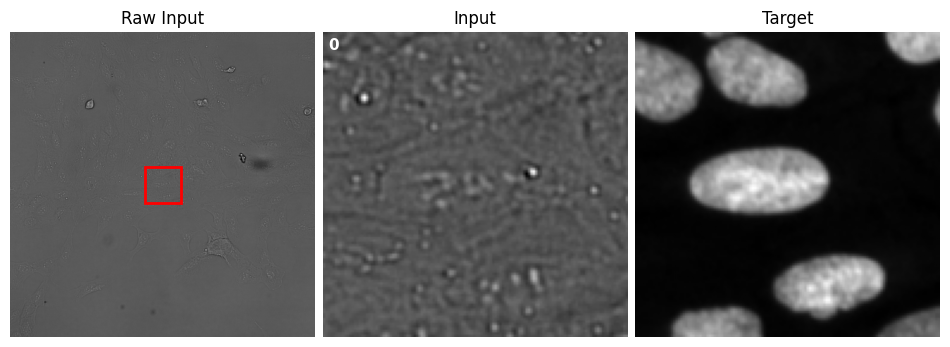

In [4]:
# Create a dataset with Brightfield as input and Hoechst as target
# See https://github.com/jump-cellpainting/2024_Chandrasekaran_NatureMethods_CPJUMP1
# for which channel codes correspond to which channel
dataset = BaseImageDataset(
    file_index=file_index,
    check_exists=True,
    pil_image_mode="I;16",
    input_channel_keys=["ch7"],
    target_channel_keys=["ch5"],
)
print(f"Dataset length: {len(dataset)}")
print(
    f"Input channels: {dataset.input_channel_keys}, target channels: {dataset._target_channel_keys}"
)

cropped_dataset = CropImageDataset.from_base_dataset(
    dataset,
    crop_size=128,    
    transforms=MaxScaleNormalize(
        normalization_factor='16bit'
    )
)
plot_dataset_grid(
    dataset=cropped_dataset,
    indices=[0],
    wspace=0.025,
    hspace=0.05
)

## Transforamtion example

In [5]:
monai_transform = Compose([
    EnsureTyped(keys=["input", "target"]),
    RandFlipd(keys=["input", "target"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["input", "target"], prob=0.5, spatial_axis=1),
    RandRotate90d(keys=["input", "target"], prob=0.5, max_k=3),
    RandAffined(
        keys=["input", "target"],
        prob=0.7,
        rotate_range=(0.0, 0.0, 0.15),
        translate_range=(0, 0), # no translate
        scale_range=(0.0, 0.0), # no scale
        padding_mode="border",
    ),
    RandGaussianSmoothd(
        keys=["input"],
        prob=0.2,
        sigma_x=(0.25, 0.5), # more aggressive smoothing to simulate out-of-focus
        sigma_y=(0.25, 0.5), 
    ),
    RandAdjustContrastd(
        keys=["input"],
        prob=0.2,
        gamma=(0.95, 1.05), # small variation to avoid unrealistic contrast change
        invert_image=False,
        retain_stats=True,
    ),
    RandGaussianNoised(
        keys=["input"],
        prob=0.2,
        mean=0.0, # no bias
        std=1e-4, # subtle salt and pepper
    ),
])

augmented_dataset = MonaiAdapter(cropped_dataset, transform=monai_transform)

## Visualize the same augmented dataset multiple times to see effects of augmentation
Note that augmentation is only applied to the crop and the shown full FOV is always un-augmented

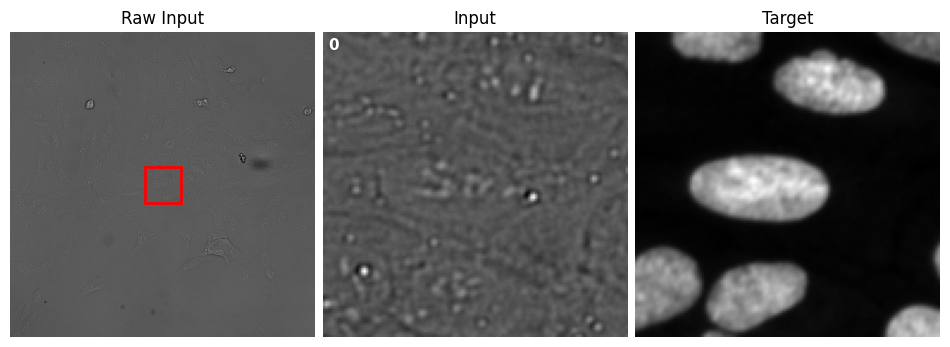

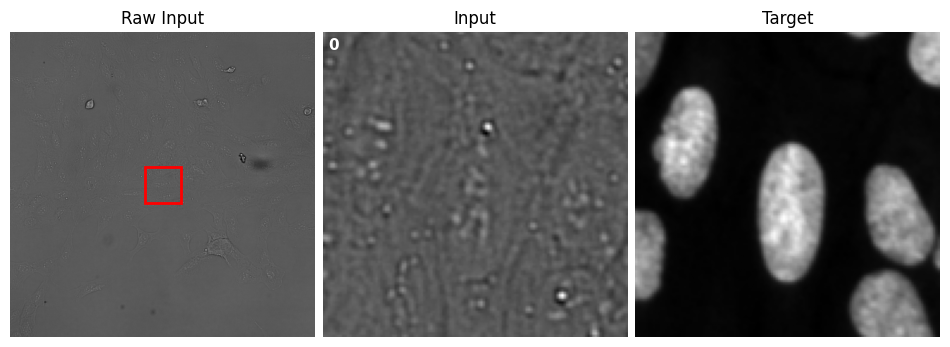

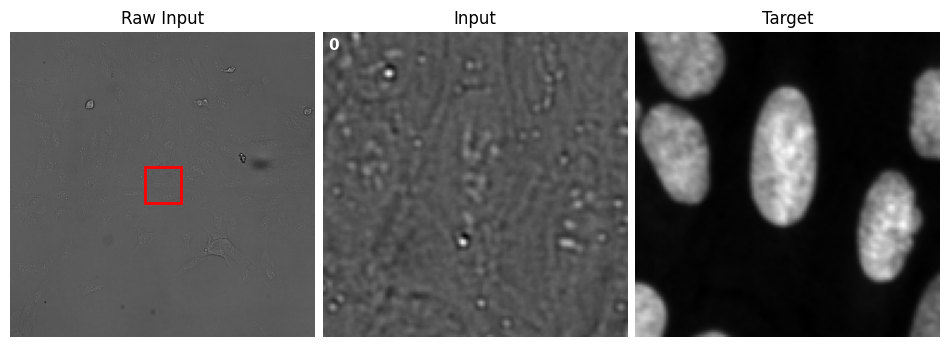

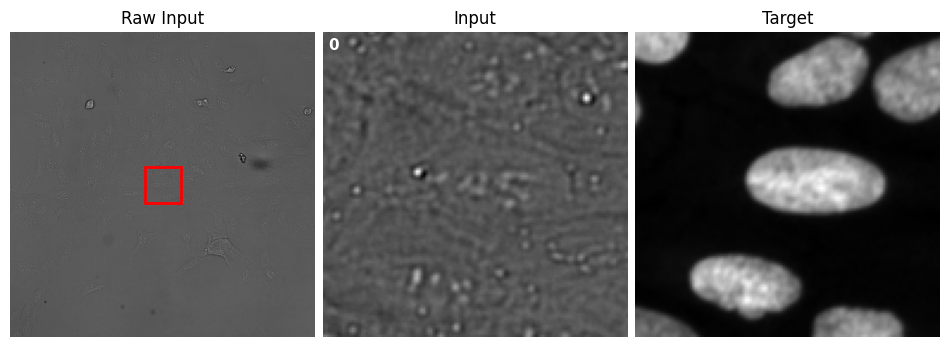

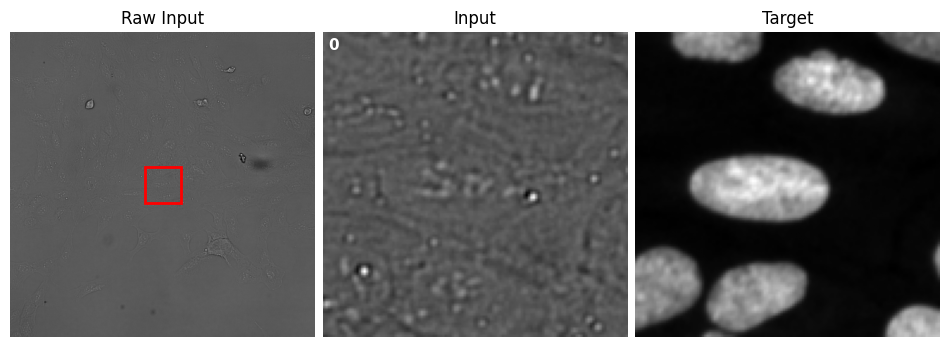

In [6]:
for i in range(5):
    plot_dataset_grid(
        dataset=augmented_dataset,
        indices=[0], # only first sample to better see difference
        wspace=0.025,
        hspace=0.05
    )

## Use `MonaiAdapter` for training as would with any image dataset

e.g.
```python
...

# Make train loader from augmented adataset
train_loader = DataLoader(
    augmented_dataset, 
    batch_size=batch_size, 
    shuffle=True,
)
...

# feed to trainer
trainer = SingleGeneratorTrainer(
    model=...,
    optimizer=...,
    losses=...,
    loss_weights=...,
    device='cuda',
    train_loader=train_loader
)

# optionally, if want to use plot prediction callback
plot_callback = PlotPredictionCallback(
    name="...",
    dataset=crop_dataset, # non-augmented dataset recommended for consistentcy
    # but augment datasets also work here
    ...
)
```